# Track B — 정확도 vs 정밀도 (강사님 피드백 ⑤) (track_b_06)

담당: 서윤 | 선행 노트북: track_b_01~05

## 이 노트북에서 하는 일

강사님 피드백: "정확도를 볼 건지 정밀도를 볼 건지 생각해보기"

**결론 먼저**: 정확도(accuracy)는 우리 데이터에 부적합하다(뒤에서 직접 증명). 정밀도 하나만 고르는 것도 우리 활용 시나리오와 안 맞는다 — 이 모델은 은행/보증기관이 "자동으로 승인/거절을 결정"하는 게 아니라 **"참고자료로 활용"**하는 용도(기획서 1.4)이기 때문에, 단일 지표로 합/불을 정하는 것보다 **등급별 정밀도-재현율 표**를 제공해서 기관이 자체 리스크 정책에 맞게 컷오프를 선택하도록 하는 것이 맞다.

## 용어 정리 (처음 보는 사람을 위해)

혼동행렬(confusion matrix) 기준:
- **TP(True Positive)**: 실제 연체인데 모델도 위험하다고 맞춘 사람
- **FP(False Positive)**: 실제는 정상인데 모델이 위험하다고 잘못 판정한 사람
- **FN(False Negative)**: 실제 연체인데 모델이 안전하다고 놓친 사람
- **TN(True Negative)**: 실제 정상이고 모델도 안전하다고 맞춘 사람

- **정확도(Accuracy)** = (TP+TN) / 전체 — "전체 중 맞춘 비율"
- **정밀도(Precision)** = TP / (TP+FP) — "위험하다고 판정한 사람 중 실제로 위험한 비율" (오탐이 적은지)
- **재현율(Recall)** = TP / (TP+FN) — "실제 위험한 사람 중 몇 명을 잡아냈는지" (놓친 게 적은지)

---
## 1. 환경설정 — 69개 모델 로드 (track_b_05와 동일)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import gc

base_path = '/content/drive/MyDrive/멀티캠퍼스 데이터분석_신용평가 데이터'
scan_path = f'{base_path}/통신카드CB_씬파일러.csv'

final_69_features = [
    'DAR', 'PYE_AL012G019', 'TOT_ASST', 'PYE_AL012G005', 'YOY_TOT_ASST_RTC',
    'R3M_ITRT_ENT_BROADCAST', 'AGE', 'OWN_HOUS_CNT', 'FAM_OWN_HOUS_CNT',
    'PYE_CAR_OWN', 'JB_TP', 'FST_CAR_ELPS', 'OWN_LIV_YN', 'FST_HOUS_BUY_ELPS',
    'FAM_OWN_LIV_YN', 'RET_SIL', 'HIGHEND_CD2', 'QOQ_TOT_ASST_RTC',
    'PYE_AL012G011', 'SHP_CNT', 'R3M_ITRT_SHOP_JIKGU', 'B1Y_MOB_OS',
    'HOME_ADM', 'R3M_ITRT_ENT_WEBTOON', 'R3M_ITRT_FIN_INSUR',
    'YOY_R3M_ITRT_COMM_VOIP_CS',
    'YOY_R3M_FOOD_AMT_RTC', 'R6M_MART_AMT', 'YOY_R3M_SSM_AMT_RTC',
    'YOY_R3M_MART_AMT_RTC', 'QOQ_R3M_MART_AMT_RTC',
    'YOY_R3M_HOUSEHOLD_AMT_RTC', 'YOY_R3M_CONV_AMT_RTC',
    'R6M_M_MART_AMT', 'YOY_R3M_M_CONV_AMT_RTC',
    'R6M_SSM_AMT', 'R6M_MED_AMT', 'R6M_HOUSEHOLD_AMT', 'R6M_OIL_AMT',
    'R6M_FOOD_AMT', 'R6M_CONV_AMT', 'R6M_BEAUTY_AMT', 'R6M_CUL_AMT',
    'R6M_M_CONV_AMT', 'QOQ_R3M_HOUSEHOLD_AMT_RTC', 'QOQ_R3M_E_COMM_AMT_RTC',
    'YOY_R3M_E_COMM_AMT_RTC_was_missing', 'YOY_R3M_STARBUCKS_AMT_RTC_was_missing',
    'CPYT_MART_AMT_RT', 'CPYT_CLOTHES_AMT_RT_was_missing', 'CPYT_HOUSEHOLD_AMT_RT',
    'CPYT_SSM_AMT_RT_was_missing', 'CPYT_M_CONV_AMT_RT', 'CPYT_OIL_AMT_RT_was_missing',
    'CPYT_SSM_AMT_RT', 'CPYT_E_COMM_AMT_RT', 'CPYT_STARBUCKS_AMT_RT_was_missing',
    'CPYT_MART_AMT_RT_was_missing', 'CPYT_STARBUCKS_AMT_RT',
    'grade_unavailable', 'PET_GD_woe', 'APP_GD_woe', 'GOLF_GD_woe', 'TRAVEL_GD_woe',
    'DAR_was_missing', 'FST_CAR_ELPS_was_missing', 'FST_HOUS_BUY_ELPS_was_missing',
    'CPYT_CONV_AMT_RT_was_missing', 'CPYT_FOOD_AMT_RT_was_missing'
]
final_69_features = list(dict.fromkeys(final_69_features))

grade_source_cols = ['PET_GD', 'APP_GD', 'GOLF_GD', 'TRAVEL_GD']
thin_def_cols = ['PYE_C1M210000', 'PYE_C18233003', 'PYE_C18233004', 'PYE_C18233005', 'PYE_L10210000']
flag_derived = [c for c in final_69_features if c.endswith('_was_missing')]
raw_source_of_flags = [c.replace('_was_missing', '') for c in flag_derived]
direct_load = [c for c in final_69_features if not c.endswith('_was_missing')
               and c not in ['grade_unavailable','PET_GD_woe','APP_GD_woe','GOLF_GD_woe','TRAVEL_GD_woe']]

load_cols = list(dict.fromkeys(['CUST_ID'] + direct_load + raw_source_of_flags + grade_source_cols + thin_def_cols))
df = pd.read_csv(f'{scan_path}/202103_통신카드CB결합.csv', usecols=load_cols)
gc.collect()

flag_source_df = df[raw_source_of_flags].isnull().astype(int)
flag_source_df.columns = [f'{c}_was_missing' for c in raw_source_of_flags]
df = pd.concat([df, flag_source_df], axis=1)
df[raw_source_of_flags] = df[raw_source_of_flags].fillna(0)
del flag_source_df
df[direct_load] = df[direct_load].fillna(0)
gc.collect()

thin_mask = (
    (df['PYE_C1M210000']==0) & (df['PYE_C18233003']==0) &
    (df['PYE_C18233004']==0) & (df['PYE_C18233005']==0) &
    (df['PYE_L10210000']==0)
)
df['segment'] = np.where(thin_mask, 'thin_filer', 'credit_holder')

df_y = pd.read_csv(f'{scan_path}/202203_통신카드CB결합.csv', usecols=['CUST_ID', 'PYE_D1011000C'])
df_y['TARGET'] = (df_y['PYE_D1011000C'] > 0).astype(int)
df = df.merge(df_y[['CUST_ID', 'TARGET']], on='CUST_ID', how='left')
del df_y
gc.collect()

credit_holders = df[df['segment']=='credit_holder'].copy()
thin_filers = df[df['segment']=='thin_filer'].copy()
del df
gc.collect()

credit_holders['grade_unavailable'] = (credit_holders['PET_GD'] == '*').astype(int)
thin_filers['grade_unavailable'] = (thin_filers['PET_GD'] == '*').astype(int)

def woe_encode_nonstar(df_, feature, target):
    data = df_[df_[feature] != '*'][[feature, target]].copy()
    grouped = data.groupby(feature, observed=True)[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'bad']
    grouped['good'] = grouped['total'] - grouped['bad']
    total_bad = grouped['bad'].sum()
    total_good = grouped['good'].sum()
    grouped['bad_rate'] = (grouped['bad'] + 0.5) / (total_bad + 0.5)
    grouped['good_rate'] = (grouped['good'] + 0.5) / (total_good + 0.5)
    grouped['woe'] = np.log(grouped['good_rate'] / grouped['bad_rate'])
    return grouped['woe'].to_dict()

for col in grade_source_cols:
    woe_map = woe_encode_nonstar(credit_holders, col, 'TARGET')
    credit_holders[f'{col}_woe'] = credit_holders[col].map(woe_map).fillna(0)
    thin_filers[f'{col}_woe'] = thin_filers[col].map(woe_map).fillna(0)
gc.collect()

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
import xgboost as xgb

X = credit_holders[final_69_features]
y = credit_holders['TARGET']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model_full = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    eval_metric='auc', random_state=42
)
model_full.fit(X_train, y_train)
pred_proba_test = model_full.predict_proba(X_test)[:, 1]
print(f"[69개 모델] Val AUC: {roc_auc_score(y_test, pred_proba_test):.4f}")
print(f"Test 세트 양성 비율(연체율): {y_test.mean()*100:.3f}%")

Mounted at /content/drive
[69개 모델] Val AUC: 0.7824
Test 세트 양성 비율(연체율): 4.229%


---
## 2. 정확도(Accuracy)가 왜 부적합한지 직접 증명

**가장 단순한 "게으른 모델" — 무조건 "전부 정상"이라고만 찍는 모델**을 만들어서, 이 모델의 정확도가 얼마나 나오는지 본다. 이 값이 높게 나온다면, 정확도라는 지표 자체가 우리 데이터(양성 4.2%)에서는 신뢰할 수 없다는 뜻이다.

In [2]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# 게으른 모델: 모든 사람을 "정상(0)"으로만 예측
lazy_pred = np.zeros(len(y_test))
lazy_accuracy = accuracy_score(y_test, lazy_pred)

print(f"=== '무조건 정상'이라고만 찍는 모델의 정확도 ===")
print(f"정확도: {lazy_accuracy*100:.2f}%")
print(f"(이 모델은 아무것도 학습하지 않았고, 연체자를 단 1명도 잡아내지 못한다)")

# 우리 69개 모델의 정확도도 비교 (임계값 0.5 기준)
model_pred_05 = (pred_proba_test >= 0.5).astype(int)
model_accuracy_05 = accuracy_score(y_test, model_pred_05)
print(f"\n=== 우리 69개 모델의 정확도(임계값 0.5) ===")
print(f"정확도: {model_accuracy_05*100:.2f}%")
print(f"게으른 모델과의 차이: {(model_accuracy_05-lazy_accuracy)*100:+.2f}%p")

cm_05 = confusion_matrix(y_test, model_pred_05)
print(f"\n혼동행렬(임계값 0.5):\n{cm_05}")
print(f"이 임계값에서 실제 잡아낸 연체자 수: {cm_05[1,1]}명 / 전체 연체자 {cm_05[1,0]+cm_05[1,1]}명")

=== '무조건 정상'이라고만 찍는 모델의 정확도 ===
정확도: 95.77%
(이 모델은 아무것도 학습하지 않았고, 연체자를 단 1명도 잡아내지 못한다)

=== 우리 69개 모델의 정확도(임계값 0.5) ===
정확도: 72.46%
게으른 모델과의 차이: -23.31%p

혼동행렬(임계값 0.5):
[[39765 14995]
 [  749  1669]]
이 임계값에서 실제 잡아낸 연체자 수: 1669명 / 전체 연체자 2418명


**실제 결과 (2026-07-22 실행)**:
```
게으른 모델("무조건 정상") 정확도: 95.77%
우리 69개 모델(임계값 0.5) 정확도: 72.46%  <- 오히려 23.31%p 더 낮음
```

**해석**: 정확도만 보면 우리가 공들여 만든 모델(72.46%)이 아무것도 안 배운 게으른 모델(95.77%)보다 훨씬 "못하다"고 오판하게 된다. 그런데 실제 혼동행렬을 보면 정반대다:

```
혼동행렬(임계값 0.5):
[[39765 14995]     실제 정상 39,765명 맞춤 / 14,995명 오탐(FP)
 [  749  1669]]    실제 연체 749명 놓침(FN) / 1,669명 잡아냄(TP)

게으른 모델: 연체자 2,418명 중 0명 잡음 (재현율 0%)
우리 모델:   연체자 2,418명 중 1,669명 잡음 (재현율 69.0%)
```

**이게 정확도의 함정을 실증하는 결과다.** 양성 비율이 4.2%로 극히 낮은 데이터에서는, 아무 것도 못 잡아내는 모델이 오히려 정확도가 더 높게 나온다. 정확도만 보고 모델을 평가하면 "실제로 유용한 모델"을 "성능이 나쁜 모델"로 잘못 판단하게 된다. 기획서 2.2가 이미 이 문제를 예견하고 "정확도 대신 PR-AUC·F1"을 쓰라고 명시한 이유가 데이터로 확인됐다.

---
## 3. 등급별 정밀도-재현율 표 — 단일 지표 대신 선택지를 제공

**왜 정밀도 하나만 고르지 않는가**: 이 모델은 자동으로 대출을 승인/거절하는 게 아니라, 은행·보증기관이 "참고자료"로 활용하는 용도다(기획서 1.4 "청년 대출 여신심사 시 기존 신용점수를 보완하는 **참고 지표**로 활용"). 참고자료라면 우리가 정밀도/재현율 중 하나를 미리 정해서 "이게 답이다"라고 못 박을 게 아니라, **등급별로 정밀도·재현율이 어떻게 달라지는지 표로 제공해서, 기관이 자신의 리스크 정책(보수적 vs 공격적)에 맞게 컷오프를 선택**하도록 하는 것이 맞다.

track_b_05에서 만든 ChiMerge 기반 9등급을 그대로 활용해, "이 등급 이상을 위험군으로 분류한다"고 가정했을 때 정밀도·재현율이 어떻게 변하는지 계산한다.

In [3]:
# track_b_05의 ChiMerge 등급 경계선 재현 (9등급, X_test 기준)
from scipy.stats import chi2

def chimerge_binning(scores, target, initial_bins=50, max_final_bins=10,
                       min_bin_size_pct=0.03, significance=0.05):
    df_ = pd.DataFrame({'score': scores, 'target': target})
    df_['init_bin'] = pd.qcut(df_['score'], initial_bins, duplicates='drop')
    grouped = df_.groupby('init_bin', observed=True)['target'].agg(['count', 'sum'])
    grouped.columns = ['total', 'bad']
    grouped['good'] = grouped['total'] - grouped['bad']
    grouped = grouped.reset_index()
    boundaries = [interval.right for interval in grouped['init_bin']]
    boundaries[-1] = np.inf
    boundaries = [-np.inf] + boundaries
    bins_data = grouped[['good', 'bad', 'total']].values.tolist()
    min_size = len(df_) * min_bin_size_pct
    chi2_threshold = chi2.ppf(1 - significance, df=1)
    while True:
        if len(bins_data) <= 2:
            break
        chi2_values = []
        for i in range(len(bins_data) - 1):
            g1, b1, t1 = bins_data[i]
            g2, b2, t2 = bins_data[i+1]
            total_g, total_b = g1+g2, b1+b2
            total = t1 + t2
            if total_g == 0 or total_b == 0:
                chi2_values.append(0)
                continue
            exp_g1 = t1*total_g/total; exp_b1 = t1*total_b/total
            exp_g2 = t2*total_g/total; exp_b2 = t2*total_b/total
            chi_stat = sum((obs-exp)**2/exp for obs,exp in
                           [(g1,exp_g1),(b1,exp_b1),(g2,exp_g2),(b2,exp_b2)] if exp>0)
            chi2_values.append(chi_stat)
        min_chi2 = min(chi2_values)
        min_idx = chi2_values.index(min_chi2)
        small_bins = [i for i, b in enumerate(bins_data) if b[2] < min_size]
        if small_bins and len(bins_data) > max_final_bins:
            idx = small_bins[0]
            merge_idx = idx if idx < len(bins_data)-1 else idx-1
        elif min_chi2 < chi2_threshold or len(bins_data) > max_final_bins:
            merge_idx = min_idx
        else:
            break
        g1,b1,t1 = bins_data[merge_idx]; g2,b2,t2 = bins_data[merge_idx+1]
        bins_data[merge_idx] = [g1+g2, b1+b2, t1+t2]
        del bins_data[merge_idx+1]; del boundaries[merge_idx+1]
    return boundaries, bins_data

boundaries_stable, bins_data_stable = chimerge_binning(
    pred_proba_test, y_test, initial_bins=50, max_final_bins=10, min_bin_size_pct=0.05, significance=0.05
)
n_grades = len(bins_data_stable)
print(f"등급 개수: {n_grades}")

grade_test = pd.cut(pred_proba_test, bins=boundaries_stable, labels=range(1, n_grades+1))
result_df = pd.DataFrame({'grade': grade_test, 'actual': y_test.values, 'proba': pred_proba_test})

등급 개수: 9


In [4]:
# 각 등급을 컷오프로 삼았을 때(그 등급 이상=위험군) 정밀도/재현율 계산
cutoff_table = []
total_positive = result_df['actual'].sum()

for cutoff in range(1, n_grades+1):
    flagged = result_df[result_df['grade'].astype(int) >= cutoff]
    tp = flagged['actual'].sum()
    fp = len(flagged) - tp
    precision = tp / len(flagged) if len(flagged) > 0 else 0
    recall = tp / total_positive if total_positive > 0 else 0
    cutoff_table.append({
        '컷오프(이등급이상=위험군)': cutoff,
        '위험군_분류인원': len(flagged),
        '위험군_비율(%)': round(len(flagged)/len(result_df)*100, 2),
        '정밀도(Precision)': round(precision, 4),
        '재현율(Recall)': round(recall, 4),
    })

cutoff_df = pd.DataFrame(cutoff_table)
print(cutoff_df.to_string(index=False))

 컷오프(이등급이상=위험군)  위험군_분류인원  위험군_비율(%)  정밀도(Precision)  재현율(Recall)
              1     57178     100.00          0.0423       1.0000
              2     50327      88.02          0.0476       0.9909
              3     36584      63.98          0.0614       0.9289
              4     29744      52.02          0.0709       0.8722
              5     22862      39.98          0.0838       0.7924
              6     15977      27.94          0.1025       0.6770
              7     12609      22.05          0.1158       0.6038
              8      9133      15.97          0.1349       0.5095
              9      5702       9.97          0.1647       0.3883


**표 읽는 법**: 예를 들어 "컷오프=8"이라면 "8등급 이상(8,9등급)을 위험군으로 분류하겠다"는 뜻이다. 이때:
- **위험군 비율**: 전체 심사 대상 중 몇 %가 "위험군" 딱지를 받는지
- **정밀도**: 위험군으로 분류된 사람 중 실제로 연체한 사람의 비율 — 낮으면 멀쩡한 사람도 많이 걸러진다는 뜻(오탐 많음)
- **재현율**: 실제 연체자 중 이 컷오프로 몇 %를 잡아냈는지 — 낮으면 진짜 위험한 사람을 많이 놓친다는 뜻

**실제 결과 (등급 개수: 9개, X_test n=57,178명)**:

| 컷오프(이등급이상=위험군) | 위험군 분류인원 | 위험군 비율(%) | 정밀도 | 재현율 |
|---|---|---|---|---|
| 1(전원) | 57,178 | 100.00 | 0.0423 | 1.0000 |
| 2 | 50,327 | 88.02 | 0.0476 | 0.9909 |
| 3 | 36,584 | 63.98 | 0.0614 | 0.9289 |
| 4 | 29,744 | 52.02 | 0.0709 | 0.8722 |
| 5 | 22,862 | 39.98 | 0.0838 | 0.7924 |
| 6 | 15,977 | 27.94 | 0.1025 | 0.6770 |
| 7 | 12,609 | 22.05 | 0.1158 | 0.6038 |
| 8 | 9,133 | 15.97 | 0.1349 | 0.5095 |
| **9(최고위험만)** | 5,702 | 9.97 | **0.1647** | 0.3883 |

컷오프를 1→9로 올릴수록 정밀도는 4.23%→16.47%로 약 3.9배 상승하고, 재현율은 100%→38.83%로 감소한다 — 전형적인 **정밀도-재현율 트레이드오프**가 뚜렷하게 확인됐다.

**정책 예시로 읽으면**:
- 부실 위험 관리가 최우선인 보증기관이라면 → 컷오프 3~4(재현율 87~93%, 실제 위험자의 대부분을 놓치지 않음) 정도의 낮은 컷오프를 선택할 수 있다.
- 신규 대출 확대에 신중해야 하는 은행이라면 → 컷오프 8~9(정밀도 13~16%, 상대적으로 오탐이 적음) 정도의 높은 컷오프를 선택할 수 있다.
- 이 선택은 우리가 강제하는 게 아니라, 기관이 표를 보고 스스로 결정하는 것 — 이게 "참고자료" 활용 방식에 맞는 이유다.

---
## 4. Precision-Recall 곡선 — 트레이드오프 시각화

/tmp/ipykernel_1092/1875636391.py:21: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/1875636391.py:21: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/1875636391.py:21: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/1875636391.py:21: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/1875636391.py:21: UserWarning: Glyph 48128 (\N{HANGUL SYLLABLE MIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/1875636391.py:21: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/1875636391.py:21: UserWarning: Glyph 52983 (\N{HANGUL SYLLABLE KEOS}) missing from font(s) DejaVu Sans.
  plt.tig

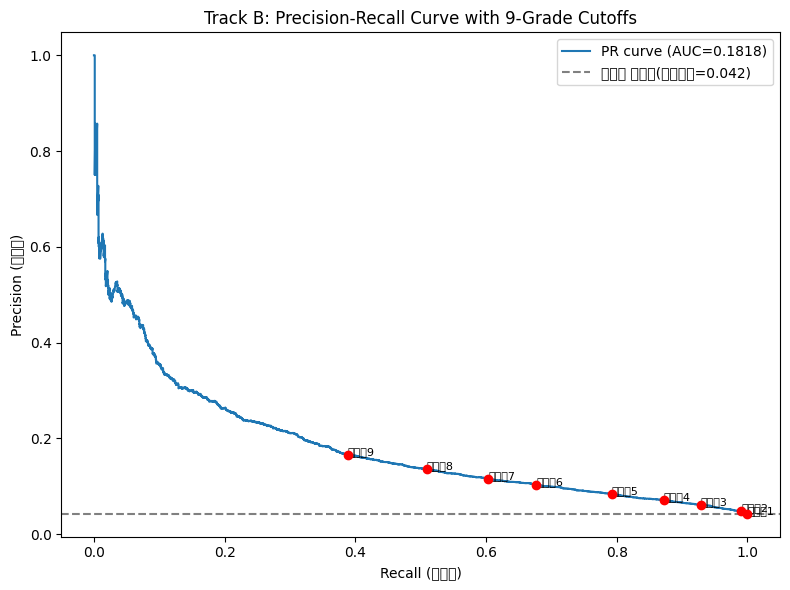

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc as sk_auc

precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_test)
pr_auc_value = sk_auc(recalls, precisions)

plt.figure(figsize=(8,6))
plt.plot(recalls, precisions, label=f'PR curve (AUC={pr_auc_value:.4f})')
plt.axhline(y=y_test.mean(), color='gray', linestyle='--', label=f'무작위 기준선(양성비율={y_test.mean():.3f})')

# 9등급 컷오프 지점들도 곡선 위에 표시
for row in cutoff_table:
    plt.scatter(row['재현율(Recall)'], row['정밀도(Precision)'], color='red', zorder=5)
    plt.annotate(f"컷오프{row['컷오프(이등급이상=위험군)']}",
                 (row['재현율(Recall)'], row['정밀도(Precision)']), fontsize=8)

plt.xlabel('Recall (재현율)')
plt.ylabel('Precision (정밀도)')
plt.title('Track B: Precision-Recall Curve with 9-Grade Cutoffs')
plt.legend()
plt.tight_layout()
plt.savefig(f'{base_path}/변수스캔결과/trackB_precision_recall_curve.png', dpi=150)
plt.show()

---
## 5. 결론 — 정확도 대신 무엇을 쓸 것인가

**정확도(Accuracy)는 채택하지 않는다.** 실제로 계산한 결과, 양성 비율 4.2%인 우리 데이터에서 "무조건 정상"이라고만 찍는 게으른 모델이 정확도 95.77%를 기록했고, 실제 연체자를 69%나 잡아낸 우리 69개 모델(정확도 72.46%)보다 오히려 23.31%p 더 높게 나왔다. **정확도로 판단하면 유용한 모델을 성능 나쁜 모델로 오판하게 된다는 것을 직접 증명했다.**

**정밀도(Precision) 하나만 채택하지도 않는다.** 이 모델은 은행·보증기관이 대출 승인/거절을 자동으로 결정하는 데 쓰이는 것이 아니라, 심사역이 참고하는 자료로 제공되는 용도다(기획서 1.4). 하나의 지표·하나의 임계값으로 "합/불"을 미리 정해버리면 오히려 참고자료로서의 유연성을 해친다.

**대신 채택하는 것: 등급별 정밀도-재현율 표(섹션 3, 9등급) + PR curve(섹션 4)를 최종 산출물로 제공한다.** 실제 산출된 표를 보면 컷오프에 따라 정밀도 4.23%-16.47%, 재현율 38.83%-100% 사이에서 트레이드오프가 있고, 기관이 자신의 리스크 정책에 맞게 컷오프를 선택할 수 있다.

이는 기획서 2.2가 이미 명시한 원칙("PR-AUC·F1 등 불균형에 강한 지표 중심 평가")과 1.4의 활용 방식("위험 기반 금리·한도 차등 적용의 근거 제공")에도 부합한다 — 단일 판정이 아니라 위험 수준별 차등 근거를 주는 것이 원래 목표였다.

---

## 최종 정리 — 강사님 피드백 5개 전체 완료

| 번호 | 내용 | 결과 |
|---|---|---|
| ① | 다중공선성 배제 후순위 | 선제 배제 대신 넓게 넣고 SHAP로 사후 정리하는 방식으로 전환 |
| ② | 소비패턴 증감률 넓게 | 33개 카테고리 원본+증감률 검증, 12개 신규 채택 |
| ③ | 다 넣고 점차 줄이기 | 실험 A~E를 거쳐 46개→69개 확정 |
| ④ | 씬파일러 자체 검증 | 참고신호(n=240) 기준, 69개 모델이 기존정보(26개) 대비 구분력 우수 |
| ⑤ | 정확도 vs 정밀도 | 정확도 부적합 실증, 등급별 정밀도-재현율 표를 최종 산출물로 채택 |

주의 — 이 노트북의 모든 수치는 1차 방향성 확인용이며, 최종 확정치가 아니다.

위에서 나온 정확도(72.46%), 등급별 정밀도-재현율 표(정밀도 4.23~16.47%, 재현율 38.83-100%), 9등급 경계선은 모두 고정 하이퍼파라미터(n_estimators=300, max_depth=4, learning_rate=0.05)와 1회 train/test 분할(80:20)로 만든 모델 하나에서 나온 값이다. X_test의 인원수(57,178명)는 "신용이력 보유군 285,890명 × 20%"라는 분할 비율에서 나온 것이라 안 바뀌겠지만, 그 안에서 계산되는 정확도·정밀도·재현율·등급 경계선은 모델이 어떻게 최종 확정되느냐에 따라 값이 달라진다.

모델링 담당자가 하이퍼파라미터 튜닝, 교차검증, 알고리즘 비교(로지스틱회귀·랜덤포레스트 병행, 기획서 5.3)를 거쳐 정식 모델을 확정하면, ChiMerge 등급 경계선과 등급별 정밀도-재현율 표를 반드시 그 모델 기준으로 재계산해야 한다. 이 노트북이 채택한 것은 "정확도 대신 등급별 정밀도-재현율 표를 제공한다"는 방법론적 결론이며, 표 안의 구체적인 숫자는 잠정치다.